# **Read data from Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

# base_path = '/content/drive/MyDrive/GP_dataset/Copy of PupilData_CSV.zip'

In [ ]:
data_path = '/content/drive/MyDrive/GP_dataset/PupilData_CSV'

In [ ]:
output_path = "/content/drive/MyDrive/GP_dataset/ProcessedData"

In [ ]:
print(os.listdir(data_path))

['Ctrl', 'off-ADHD', 'on-ADHD']


# **Preprocessing**

In [ ]:
import os
import pandas as pd
import numpy as np
from scipy.signal import butter, filtfilt

In [ ]:
os.makedirs(output_path, exist_ok=True)

In [ ]:
def lowpass_filter(signal, high=0.6, fs=1000, order=4):
    """Lowpass filter فقط - أ stabler من bandpass"""
    nyq = 0.5 * fs
    high_cut = high / nyq
    b, a = butter(order, high_cut, btype='low')
    return filtfilt(b, a, signal)

def apply_filter2(trial_df):
    trial_df["Diameter_filt"] = lowpass_filter(trial_df["Diameter_bc"].values)
    return trial_df

In [ ]:
def baseline_correct(trial_df):
    baseline = trial_df["Diameter"].iloc[:50]  # adjust if needed
    baseline_mean = baseline.mean()
    trial_df["Diameter_bc"] = trial_df["Diameter"] - baseline_mean
    return trial_df

In [ ]:
def handle_nans(trial_df):
    trial_df["Diameter_bc"] = trial_df["Diameter_bc"].interpolate()
    # trial_df["Diameter_bc"] = trial_df["Diameter_bc"].fillna(
    #     trial_df["Diameter_bc"].mean()
    # )
    if trial_df["Diameter_bc"].isna().any():
        fill_value = trial_df["Diameter_bc"].dropna().mean()
        if pd.isna(fill_value):
            fill_value = 0
        trial_df["Diameter_bc"] = trial_df["Diameter_bc"].fillna(fill_value)

    return trial_df

In [ ]:
def preprocess_trial(trial_df):
    trial_df = trial_df.copy()

    trial_df = baseline_correct(trial_df)

    trial_df = handle_nans(trial_df)

    trial_df = apply_filter2(trial_df)

    return trial_df

In [ ]:
def process_session2(session_path):
    print(f"Processing: {session_path}")

    task_df = pd.read_csv(os.path.join(session_path, "task_data.csv"))
    epochs_df = pd.read_csv(os.path.join(session_path, "task_epocs.csv"))

    task_df = task_df.dropna(subset=["Time"]).reset_index(drop=True)

    time_array = task_df["Time"].values

    TRIAL_LEN = 8000  # or 8250 later

    trials = []
    for i, row in epochs_df.iterrows():
        start_time = row["Pupil_2_1"]


        start_idx = np.argmin(np.abs(time_array - start_time))

        end_idx = start_idx + TRIAL_LEN

        trial_df = task_df.iloc[start_idx:end_idx].copy()

        trial_df["trial_id"] = i  # important for later merge
        print(f"trial{i} detected: {len(trial_df)} samples")
        trials.append(trial_df)

    print("Number of trials:", len(trials))

    processed_trials = []

    for i, trial_df in enumerate(trials):
        try:
            processed = preprocess_trial(trial_df)
            processed["trial_id"] = (i+1)
            processed_trials.append(processed)
        except Exception as e:
            print(f"Error in trial {i}: {e}")

    session_data = pd.concat(processed_trials, ignore_index=True)

    return session_data

In [ ]:
groups = ['Ctrl', 'off-ADHD', 'on-ADHD']

count=0
all_filtered_values = []
all_data = {
    'Ctrl': {},
    'off-ADHD': {},
    'on-ADHD': {}
}

for group in groups:
    group_path = os.path.join(data_path, group)

    for session in os.listdir(group_path):
        session_path = os.path.join(group_path, session)

        if os.path.isdir(session_path):
            session_data = process_session2(session_path)

            if session_data is not None:
              all_data[group][session] = session_data
              all_filtered_values.append(session_data["Diameter_filt"].values)
              print(f"✅ {group}/{session} loaded")

all_values = np.concatenate(all_filtered_values)
GLOBAL_MEAN = np.mean(all_values)
GLOBAL_STD = np.std(all_values)

print(f"GLOBAL_MEAN = {GLOBAL_MEAN}")
print(f"GLOBAL_STD = {GLOBAL_STD}")

#to be used in android
np.save("eye_global_mean.npy", GLOBAL_MEAN)
np.save("eye_global_std.npy", GLOBAL_STD)
print("✅ Global stats saved for Android")

Streaming output truncated to the last 5000 lines.
trial55 detected: 8000 samples
trial56 detected: 8000 samples
trial57 detected: 8000 samples
trial58 detected: 8000 samples
trial59 detected: 8000 samples
trial60 detected: 8000 samples
trial61 detected: 8000 samples
trial62 detected: 8000 samples
trial63 detected: 8000 samples
trial64 detected: 8000 samples
trial65 detected: 8000 samples
trial66 detected: 8000 samples
trial67 detected: 8000 samples
trial68 detected: 8000 samples
trial69 detected: 8000 samples
trial70 detected: 8000 samples
trial71 detected: 8000 samples
trial72 detected: 8000 samples
trial73 detected: 8000 samples
trial74 detected: 8000 samples
trial75 detected: 8000 samples
trial76 detected: 8000 samples
trial77 detected: 8000 samples
trial78 detected: 8000 samples
trial79 detected: 8000 samples
trial80 detected: 8000 samples
trial81 detected: 8000 samples
trial82 detected: 8000 samples
trial83 detected: 8000 samples
trial84 detected: 8000 samples
trial85 detected: 8

In [ ]:
for group in groups:
    for session, df in all_data[group].items():
        df["Diameter_z"] = (df["Diameter_filt"] - GLOBAL_MEAN) / GLOBAL_STD

print("✅ Global Z-score applied!")

✅ Global Z-score applied!


In [ ]:
print("Summary:")
for group in groups:
    print(f"  {group}: {len(all_data[group])} sessions")
print("="*50)

Summary:
  Ctrl: 22 sessions
  off-ADHD: 28 sessions
  on-ADHD: 17 sessions


# **Feature Extraction**

In [ ]:
# ============================================
# Cell 1: Import libraries and setup paths
# ============================================

import pandas as pd
import numpy as np
import os

# Paths
output_path = "/content/drive/MyDrive/GP_dataset/ProcessedData"
raw_data_path = "/content/drive/MyDrive/GP_dataset/PupilData_CSV"
groups = ['Ctrl', 'off-ADHD', 'on-ADHD']

print("Libraries imported successfully")
print(f"Output path: {output_path}")
print(f"Raw data path: {raw_data_path}")
print(f"Groups: {groups}")

Libraries imported successfully
Output path: /content/drive/MyDrive/GP_dataset/ProcessedData
Raw data path: /content/drive/MyDrive/GP_dataset/PupilData_CSV
Groups: ['Ctrl', 'off-ADHD', 'on-ADHD']


In [ ]:
# ============================================
# Cell 2: Extract pupil features (size, constriction, dilation rates)
# from processed data (task_data_processed.csv)
# ============================================

def extract_pupil_features(df, session, group):
    """
    Extract pupil-based features for each block (1-8)
    Features: max, mean, median pupil size + constriction/dilation rates
    """

    df['block'] = ((df['trial_id'] - 1) // 20) + 1

    session_features = {
        'subject': session,
        'group': group
    }

    for block_id in range(1, 9):
        block_df = df[df['block'] == block_id]

        if len(block_df) == 0:
            for feature in ['max_pupil', 'mean_pupil', 'median_pupil',
                           'max_contraction', 'mean_contraction', 'median_contraction',
                           'max_dilation', 'mean_dilation', 'median_dilation']:
                session_features[f'{feature}_{block_id}'] = np.nan
            continue

        pupil_vals = block_df['Diameter_z'].values

        max_pupil = np.max(pupil_vals)
        mean_pupil = np.mean(pupil_vals)
        median_pupil = np.median(pupil_vals)

        rates = np.diff(pupil_vals)

        # Constriction rates (negative values)
        contraction_rates = rates[rates < 0]
        if len(contraction_rates) > 0:
            max_contraction = np.min(contraction_rates)  # most negative = fastest constriction
            mean_contraction = np.mean(contraction_rates)
            median_contraction = np.median(contraction_rates)
        else:
            max_contraction = mean_contraction = median_contraction = 0

        # Dilation rates (positive values)
        dilation_rates = rates[rates > 0]
        if len(dilation_rates) > 0:
            max_dilation = np.max(dilation_rates)
            mean_dilation = np.mean(dilation_rates)
            median_dilation = np.median(dilation_rates)
        else:
            max_dilation = mean_dilation = median_dilation = 0

        # Store features with block suffix
        session_features[f'max_pupil_{block_id}'] = max_pupil
        session_features[f'mean_pupil_{block_id}'] = mean_pupil
        session_features[f'median_pupil_{block_id}'] = median_pupil

        session_features[f'max_contraction_{block_id}'] = max_contraction
        session_features[f'mean_contraction_{block_id}'] = mean_contraction
        session_features[f'median_contraction_{block_id}'] = median_contraction

        session_features[f'max_dilation_{block_id}'] = max_dilation
        session_features[f'mean_dilation_{block_id}'] = mean_dilation
        session_features[f'median_dilation_{block_id}'] = median_dilation

    return session_features


all_pupil_features = []

for group in groups:
    for session, df in all_data[group].items():
      print(f"Processing: {group} - {session}")

      if 'trial_id' not in df.columns or 'Diameter_z' not in df.columns:
            print(f"  Required columns missing in {session}")
            continue

      features = extract_pupil_features(df, session, group)
      all_pupil_features.append(features)

pupil_features_df = pd.DataFrame(all_pupil_features)

print(f"\nExtracted pupil features for {len(pupil_features_df)} participants")
print(f"Total columns: {len(pupil_features_df.columns)}")
print(pupil_features_df.head())

Processing: Ctrl - subject_29_session_1
Processing: Ctrl - subject_30_session_2
Processing: Ctrl - subject_31_session_3
Processing: Ctrl - subject_32_session_4
Processing: Ctrl - subject_33_session_5
Processing: Ctrl - subject_34_session_6
Processing: Ctrl - subject_35_session_7
Processing: Ctrl - subject_36_session_8
Processing: Ctrl - subject_37_session_9
Processing: Ctrl - subject_38_session_10
Processing: Ctrl - subject_39_session_11
Processing: Ctrl - subject_40_session_12
Processing: Ctrl - subject_41_session_13
Processing: Ctrl - subject_42_session_14
Processing: Ctrl - subject_43_session_15
Processing: Ctrl - subject_44_session_16
Processing: Ctrl - subject_45_session_17
Processing: Ctrl - subject_46_session_18
Processing: Ctrl - subject_47_session_19
Processing: Ctrl - subject_48_session_20
Processing: Ctrl - subject_49_session_21
Processing: Ctrl - subject_50_session_22
Processing: off-ADHD - subject_10_session_1
Processing: off-ADHD - subject_11_session_2
Processing: off-ADH

In [ ]:
# ============================================
# Cell 3: Extract task performance and reaction time features
# from raw epocs file (task_epocs.csv)
# Features: correct/incorrect responses (high/low load), reaction time
# ============================================

def extract_performance_features(epocs_df, session, group):

    session_features = {
        'subject': session,
        'group': group
    }

    for block_id in range(1, 9):
        start_idx = (block_id - 1) * 20
        end_idx = block_id * 20
        block_df = epocs_df.iloc[start_idx:end_idx]

        if len(block_df) == 0:
            continue

        # Count correct/incorrect responses
        # Load: 1 = low load, 2 = high load
        # Performance: 1 = correct, 0 = incorrect

        low_load_mask = block_df['Load'] == 1
        high_load_mask = block_df['Load'] == 2

        low_load_correct = ((block_df['Load'] == 1) & (block_df['Perform'] == 1)).sum()
        low_load_incorrect = ((block_df['Load'] == 1) & (block_df['Perform'] == 0)).sum()

        high_load_correct = ((block_df['Load'] == 2) & (block_df['Perform'] == 1)).sum()
        high_load_incorrect = ((block_df['Load'] == 2) & (block_df['Perform'] == 0)).sum()

        # Reaction time features (excluding NaN values)
        rt_values = block_df['Rtime'].dropna().values

        if len(rt_values) > 0:
            max_rt = np.max(rt_values)
            mean_rt = np.mean(rt_values)
            median_rt = np.median(rt_values)
        else:
            max_rt = mean_rt = median_rt = np.nan

        # Store features
        session_features[f'low_load_correct_{block_id}'] = low_load_correct
        session_features[f'low_load_incorrect_{block_id}'] = low_load_incorrect
        session_features[f'high_load_correct_{block_id}'] = high_load_correct
        session_features[f'high_load_incorrect_{block_id}'] = high_load_incorrect

        session_features[f'max_rt_{block_id}'] = max_rt
        session_features[f'mean_rt_{block_id}'] = mean_rt
        session_features[f'median_rt_{block_id}'] = median_rt

    return session_features


all_performance_features = []

for group in groups:
    group_raw_path = os.path.join(raw_data_path, group)

    if not os.path.exists(group_raw_path):
        print(f"Directory not found: {group_raw_path}")
        continue

    for session in os.listdir(group_raw_path):
        session_raw_path = os.path.join(group_raw_path, session)
        epocs_file = os.path.join(session_raw_path, "task_epocs.csv")

        if not os.path.exists(epocs_file):
            print(f"Epocs file not found: {epocs_file}")
            continue

        print(f"Processing performance: {group} - {session}")

        epocs_df = pd.read_csv(epocs_file)

        required_cols = ['Load', 'Perform', 'Rtime']
        if not all(col in epocs_df.columns for col in required_cols):
            print(f"  Required columns missing in {session}")
            continue

        features = extract_performance_features(epocs_df, session, group)
        all_performance_features.append(features)

# Convert to DataFrame
performance_features_df = pd.DataFrame(all_performance_features)

print(f"\nExtracted performance features for {len(performance_features_df)} participants")
print(f"Total columns: {len(performance_features_df.columns)}")
print(performance_features_df.head())

Processing performance: Ctrl - subject_29_session_1
Processing performance: Ctrl - subject_30_session_2
Processing performance: Ctrl - subject_31_session_3
Processing performance: Ctrl - subject_32_session_4
Processing performance: Ctrl - subject_33_session_5
Processing performance: Ctrl - subject_34_session_6
Processing performance: Ctrl - subject_35_session_7
Processing performance: Ctrl - subject_36_session_8
Processing performance: Ctrl - subject_37_session_9
Processing performance: Ctrl - subject_38_session_10
Processing performance: Ctrl - subject_39_session_11
Processing performance: Ctrl - subject_40_session_12
Processing performance: Ctrl - subject_41_session_13
Processing performance: Ctrl - subject_42_session_14
Processing performance: Ctrl - subject_43_session_15
Processing performance: Ctrl - subject_44_session_16
Processing performance: Ctrl - subject_45_session_17
Processing performance: Ctrl - subject_46_session_18
Processing performance: Ctrl - subject_47_session_19
Pr

In [ ]:
# ============================================
# Cell 4: Merge pupil features and performance features
# into a single final DataFrame for modeling
# ============================================

# Merge on subject and group
final_df = pd.merge(pupil_features_df, performance_features_df,
                    on=['subject', 'group'], how='outer')

# Add target label (1 = ADHD, 0 = Control)
final_df['label'] = final_df['group'].apply(lambda x: 1 if x in ['on-ADHD', 'off-ADHD'] else 0)

# Display info
print("=" * 60)
print("FINAL DATASET FOR MODELING")
print("=" * 60)
print(f"Total samples: {len(final_df)}")
print(f"Total features: {len(final_df.columns) - 3} (excluding subject, group, label)")
print(f"\nClass distribution:")
print(final_df['label'].value_counts().to_string())
print(f"  0 = Control, 1 = ADHD\n")

print("First 5 rows:")
print(final_df.head())

FINAL DATASET FOR MODELING
Total samples: 67
Total features: 128 (excluding subject, group, label)

Class distribution:
label
1    45
0    22
  0 = Control, 1 = ADHD

First 5 rows:
                subject     group  max_pupil_1  mean_pupil_1  median_pupil_1  \
0  subject_10_session_1  off-ADHD     3.510489      0.488211        0.077847   
1  subject_11_session_1   on-ADHD     4.234904      0.550269        0.142549   
2  subject_11_session_2  off-ADHD     3.930867      0.493434        0.085624   
3  subject_12_session_2   on-ADHD     4.017194      0.370296       -0.061220   
4  subject_12_session_3  off-ADHD     3.665493      0.006845       -0.108559   

   max_contraction_1  mean_contraction_1  median_contraction_1  \
0          -3.344043           -0.000515             -0.000163   
1          -4.361920           -0.000907             -0.000603   
2          -3.708578           -0.000519             -0.000191   
3          -3.788153           -0.000517             -0.000183   
4       

In [ ]:
features_path = "/content/drive/MyDrive/GP_dataset/FeatureExtraction"

In [ ]:
# Save to CSV
save_file = os.path.join(output_path, "final_features_dataset.csv")
final_df.to_csv(save_file, index=False)
print(f"\nDataset saved to: {save_file}")


Dataset saved to: /content/drive/MyDrive/GP_dataset/ProcessedData/final_features_dataset.csv


In [ ]:
# ============================================
# Cell 5: Quick statistical summary of features
# ============================================

from scipy import stats

print("=" * 60)
print("STATISTICAL COMPARISON: ADHD vs CONTROL")
print("=" * 60)

# Separate by group
adhd_df = final_df[final_df['label'] == 1]
control_df = final_df[final_df['label'] == 0]

key_features = final_df.columns[2:]

for feature in key_features:
    adhd_vals = adhd_df[feature].dropna()
    control_vals = control_df[feature].dropna()

    if len(adhd_vals) > 1 and len(control_vals) > 1:
        t_stat, p_val = stats.ttest_ind(adhd_vals, control_vals)
        print(f"{feature:30} | ADHD mean: {adhd_vals.mean():.3f} | Control mean: {control_vals.mean():.3f} | p-value: {p_val:.4f}")
    else:
        print(f"{feature:30} | Insufficient data")




STATISTICAL COMPARISON: ADHD vs CONTROL
max_pupil_1                    | ADHD mean: 2.833 | Control mean: 2.397 | p-value: 0.3304
mean_pupil_1                   | ADHD mean: 0.074 | Control mean: 0.079 | p-value: 0.9200
median_pupil_1                 | ADHD mean: -0.050 | Control mean: 0.008 | p-value: 0.0250
max_contraction_1              | ADHD mean: -2.276 | Control mean: -1.783 | p-value: 0.2022
mean_contraction_1             | ADHD mean: -0.000 | Control mean: -0.000 | p-value: 0.1222
median_contraction_1           | ADHD mean: -0.000 | Control mean: -0.000 | p-value: 0.5148
max_dilation_1                 | ADHD mean: 2.217 | Control mean: 1.607 | p-value: 0.0677
mean_dilation_1                | ADHD mean: 0.001 | Control mean: 0.000 | p-value: 0.0485
median_dilation_1              | ADHD mean: 0.000 | Control mean: 0.000 | p-value: 0.6178
max_pupil_2                    | ADHD mean: 3.036 | Control mean: 2.143 | p-value: 0.0341
mean_pupil_2                   | ADHD mean: 0.032 | C

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
key_features

Index(['max_pupil_1', 'mean_pupil_1', 'median_pupil_1', 'max_contraction_1',
       'mean_contraction_1', 'median_contraction_1', 'max_dilation_1',
       'mean_dilation_1', 'median_dilation_1', 'max_pupil_2',
       ...
       'mean_rt_7', 'median_rt_7', 'low_load_correct_8',
       'low_load_incorrect_8', 'high_load_correct_8', 'high_load_incorrect_8',
       'max_rt_8', 'mean_rt_8', 'median_rt_8', 'label'],
      dtype='object', length=129)

In [ ]:
!pip install pingouin

In [ ]:
import pingouin as pg
import pandas as pd

featuresForANOVA =  ['max_pupil',
 'mean_pupil',
 'median_pupil',
 'max_contraction',
 'mean_contraction',
 'median_contraction',
 'max_dilation',
 'mean_dilation',
 'median_dilation',
 'low_load_correct',
 'low_load_incorrect',
 'high_load_correct',
 'high_load_incorrect',
 'max_rt',
 'mean_rt',
 'median_rt']


selected_features = []


for feature in featuresForANOVA:
    cols = [f"{feature}_{i}" for i in range(1, 9)]

    df_long = final_df.melt(
        id_vars=['subject', 'group'],
        value_vars=cols,
        var_name="block",
        value_name=feature
    )

    df_long["block"] = df_long["block"].str.extract(r"_(\d+)").astype(int)

    try:
        aov = pg.mixed_anova(
            dv=feature,
            within="block",
            between="group",
            subject="subject",
            data=df_long
        )

        p_group = aov.loc[aov['Source'] == 'group', 'p_unc'].values[0]
        p_interaction = aov.loc[aov['Source'] == 'Interaction', 'p_unc'].values[0]

        print(f"\nFeature: {feature}")
        print(aov)
        if (p_group < 0.05) or (p_interaction < 0.05):
            posthoc = pg.pairwise_tests(
                dv=feature,
                between="group",
                within='block',
                subject="subject",
                data=df_long,
                padjust='holm'
            )
            print("\nPosthoc:")
            print(posthoc)

            # Check if any significant comparison exists
            if (posthoc['p_corr'] < 0.05).any():
                selected_features.append(feature)
                print("✅ FEATURE KEPT")
            else:
                print("❌ No significant posthoc → REJECTED")
        else:
                print("❌ ANOVA not significant → REJECTED")
    except Exception as e:
        print(f"\nFeature: {feature} -> Error in ANOVA: {e} → SKIPPED")
print("\n" + "="*50)
print("\nSelected Features:")
print(selected_features)


Feature: max_pupil
        Source          SS  DF1  DF2         MS         F     p_unc       np2  \
0        group  108.823361    2   64  54.411680  5.754290  0.005034  0.152414   
1        block    9.434332    7  448   1.347762  0.663409  0.703112  0.010259   
2  Interaction   43.427095   14  448   3.101935  1.526867  0.097612  0.045542   

        eps  
0       NaN  
1  0.878063  
2       NaN  

Posthoc:
         Contrast block         A         B Paired Parametric         T  \
0           block     -         1         2   True       True -0.192608   
1           block     -         1         3   True       True  0.197306   
2           block     -         1         4   True       True  1.083775   
3           block     -         1         5   True       True  0.774136   
4           block     -         1         6   True       True  0.146981   
5           block     -         1         7   True       True  1.279815   
6           block     -         1         8   True       True  1

In [ ]:
selected_features

['max_pupil',
 'median_pupil',
 'max_contraction',
 'mean_contraction',
 'max_dilation',
 'mean_dilation',
 'low_load_correct',
 'low_load_incorrect',
 'high_load_correct',
 'high_load_incorrect']

In [ ]:
model_df = final_df[["subject", "group"]].copy()

for feature in selected_features:
    cols = [f"{feature}_{i}" for i in range(1, 9)]
    model_df = pd.concat([model_df, final_df[cols]], axis=1)

In [ ]:
model_X = model_df.drop(columns=['subject', 'group'])
model_Y = model_df['group'].apply(lambda x: 1 if x in ['on-ADHD', 'off-ADHD'] else 0)

print(f"Final DataFrame shape: {model_df.shape}")
print(f"X shape: {model_X.shape}")
print(f"y shape: {model_Y.shape}")
print(f"\nFeatures count: {model_X.shape[1]}")

Final DataFrame shape: (67, 82)
X shape: (67, 80)
y shape: (67,)

Features count: 80


In [ ]:
model_X.head(20)

,max_pupil_1,max_pupil_2,max_pupil_3,max_pupil_4,max_pupil_5,max_pupil_6,max_pupil_7,max_pupil_8,median_pupil_1,median_pupil_2,...,high_load_correct_7,high_load_correct_8,high_load_incorrect_1,high_load_incorrect_2,high_load_incorrect_3,high_load_incorrect_4,high_load_incorrect_5,high_load_incorrect_6,high_load_incorrect_7,high_load_incorrect_8
0,3.510489,3.395593,3.493646,4.083735,3.505141,3.601817,3.391819,3.688933,0.077847,0.059373,...,5,1,7,5,3,0,6,4,2,7
1,4.234904,3.860432,4.929076,3.844609,4.887664,4.623519,3.768088,4.899209,0.142549,0.002019,...,5,4,1,5,3,2,4,4,1,6
2,3.930867,3.728988,4.319464,3.956684,5.244011,3.786179,4.339320,4.443055,0.085624,-0.045571,...,3,6,6,2,3,2,3,4,3,2
3,4.017194,0.468238,4.485613,0.505280,0.754359,0.507493,0.581471,0.393051,-0.061220,-0.112610,...,1,3,5,2,6,1,5,4,5,7
4,3.665493,3.250984,0.427332,3.657658,0.628697,3.568542,0.538973,0.121733,-0.108559,-0.155076,...,4,7,2,2,5,5,7,9,3,3
5,0.903524,4.433561,0.723974,0.677305,1.112457,0.862927,1.382578,1.236722,-0.188261,-0.187251,...,4,5,4,4,5,4,3,10,3,5
6,4.533742,4.837560,5.598981,4.962854,6.896664,6.118087,5.706278,5.131774,-0.101705,-0.082829,...,2,3,2,5,5,3,3,6,0,3
7,5.107573,1.424964,0.883175,1.420577,5.048801,4.529691,1.402431,4.830721,0.134647,0.009768,...,1,2,4,3,4,2,2,3,2,2
8,4.341235,0.834447,0.896271,4.175213,0.860390,0.809341,0.655798,0.844106,0.009746,0.072321,...,5,6,3,2,4,3,2,7,2,4
9,0.727034,5.409659,4.512261,4.226729,1.054615,1.080703,0.821121,4.445037,-0.041266,-0.023616,...,5,5,3,4,6,4,3,4,2,5


In [ ]:
model_X = model_X.fillna(model_X.mean())

# **Models**

In [ ]:
# ============================================
# Cell 6: Install required libraries
# ============================================

!pip install scikit-learn tensorflow matplotlib seaborn imbalanced-learn -q

print("All required libraries installed")

All required libraries installed


In [ ]:
# ============================================
# Cell 7: Import all libraries for modeling
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn imports
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
from sklearn.impute import SimpleImputer

# imbalanced-learn
from imblearn.over_sampling import SMOTE

# tensorflow / keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, LSTM, Conv1D, Conv2D,
    BatchNormalization, Flatten, Concatenate,
    Attention, MultiHeadAttention, Reshape,
    GlobalAveragePooling1D, GlobalMaxPooling1D,
    Add, LayerNormalization, MaxPooling1D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# Gaussian Mixture Model from sklearn
from sklearn.mixture import GaussianMixture

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("All libraries imported successfully")
print(f"TensorFlow version: {tf.__version__}")

All libraries imported successfully
TensorFlow version: 2.20.0


In [ ]:
# ============================================
# Cell 8: Load the extracted features and prepare for modeling
# ============================================

print(f"\nFeatures shape: {model_X.shape}")
print(f"Labels shape: {model_Y.shape}")
print(f"\nClass distribution before SMOTE:\n{model_Y.value_counts().to_string()}")

# Handle missing values (impute with mean)
imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(model_X), columns=model_X.columns)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print(f"\nAfter imputation and scaling: {X_scaled.shape}")


Features shape: (67, 80)
Labels shape: (67,)

Class distribution before SMOTE:
group
1    45
0    22

After imputation and scaling: (67, 80)


In [ ]:
import joblib

joblib.dump(scaler, 'feature_scaler.pkl')
joblib.dump(imputer, 'feature_imputer.pkl')

print("\nScaler and Imputer saved for Android")


Scaler and Imputer saved for Android


In [ ]:
model_Y.head()

,group
0,1
1,1
2,1
3,1
4,1


In [ ]:
# ============================================
# Cell 9: Apply SMOTE to balance the classes
# Note: SMOTE applied AFTER feature extraction (as per paper)
# ============================================

# Apply SMOTE
smote = SMOTE(random_state=42)

X_balanced, y_balanced = smote.fit_resample(X_scaled, model_Y)
y_balanced = y_balanced.squeeze()
print(f"After SMOTE:")
print(f"X_balanced shape: {X_balanced.shape}")
print(f"y_balanced shape: {y_balanced.shape}")
print(f"Class distribution:\n{pd.Series(y_balanced).value_counts().to_string()}")

After SMOTE:
X_balanced shape: (90, 80)
y_balanced shape: (90,)
Class distribution:
group
1    45
0    45


In [ ]:

# Reshape for sequential models: (samples, time_steps, features)
# Each sample has 8 blocks (time steps) with N features per block
n_blocks = 8
n_features_per_block = len(selected_features)

print(f"\nNumber of blocks (time steps): {n_blocks}")
print(f"Features per block: {n_features_per_block}")

correct_order = []
for b in range(1, n_blocks + 1):
    for feature in selected_features:
        correct_order.append(f"{feature}_{b}")
print(correct_order)


Number of blocks (time steps): 8
Features per block: 10
['max_pupil_1', 'median_pupil_1', 'max_contraction_1', 'mean_contraction_1', 'max_dilation_1', 'mean_dilation_1', 'low_load_correct_1', 'low_load_incorrect_1', 'high_load_correct_1', 'high_load_incorrect_1', 'max_pupil_2', 'median_pupil_2', 'max_contraction_2', 'mean_contraction_2', 'max_dilation_2', 'mean_dilation_2', 'low_load_correct_2', 'low_load_incorrect_2', 'high_load_correct_2', 'high_load_incorrect_2', 'max_pupil_3', 'median_pupil_3', 'max_contraction_3', 'mean_contraction_3', 'max_dilation_3', 'mean_dilation_3', 'low_load_correct_3', 'low_load_incorrect_3', 'high_load_correct_3', 'high_load_incorrect_3', 'max_pupil_4', 'median_pupil_4', 'max_contraction_4', 'mean_contraction_4', 'max_dilation_4', 'mean_dilation_4', 'low_load_correct_4', 'low_load_incorrect_4', 'high_load_correct_4', 'high_load_incorrect_4', 'max_pupil_5', 'median_pupil_5', 'max_contraction_5', 'mean_contraction_5', 'max_dilation_5', 'mean_dilation_5', '

In [ ]:
col_indices = [list(model_X.columns).index(col) for col in correct_order]
print(col_indices)

[0, 8, 16, 24, 32, 40, 48, 56, 64, 72, 1, 9, 17, 25, 33, 41, 49, 57, 65, 73, 2, 10, 18, 26, 34, 42, 50, 58, 66, 74, 3, 11, 19, 27, 35, 43, 51, 59, 67, 75, 4, 12, 20, 28, 36, 44, 52, 60, 68, 76, 5, 13, 21, 29, 37, 45, 53, 61, 69, 77, 6, 14, 22, 30, 38, 46, 54, 62, 70, 78, 7, 15, 23, 31, 39, 47, 55, 63, 71, 79]


In [ ]:
X_balanced = X_balanced[:, col_indices]

In [ ]:
import json

with open('feature_order.json', 'w') as f:
    json.dump(correct_order, f)

print("\n✅ Feature order saved for Android!")


✅ Feature order saved for Android!


In [ ]:
# Reshape to (samples, blocks, features_per_block)
X_reshaped = X_balanced.reshape(-1, n_blocks, n_features_per_block)

print(f"\nNumber of blocks (time steps): {n_blocks}")
print(f"Features per block: {n_features_per_block}")
print(f"Final shape for sequential models: {X_reshaped.shape}")


Number of blocks (time steps): 8
Features per block: 10
Final shape for sequential models: (90, 8, 10)


In [ ]:
# from sklearn.preprocessing import LabelEncoder

# le = LabelEncoder()
# y_balanced = le.fit_transform(y_balanced)

In [ ]:
 # ============================================
# Cell 10: Define CLAGNet Model
# Hybrid: CNN + LSTM + Attention + GMM
# Based on the paper description
# ============================================

class CLAGNet(Model):
    """
    CLAGNet: Hybrid CNN-LSTM-Attention-GMM Network for ADHD Classification
    """
    def __init__(self, time_steps, features_per_step, n_classes=2,
                 lstm_units=64, dropout_rate=0.3, kernel_size=3):
        super(CLAGNet, self).__init__()

        self.time_steps = time_steps
        self.features_per_step = features_per_step
        self.n_classes = n_classes
        self.lstm_units = lstm_units
        self.dropout_rate = dropout_rate
        self.kernel_size = kernel_size

        # ========== CNN Branch (for spatial/local features) ==========
        self.conv1 = Conv1D(filters=32, kernel_size=kernel_size, activation='relu', padding='same')
        self.bn1 = BatchNormalization()
        self.dropout1 = Dropout(dropout_rate)

        self.conv2 = Conv1D(filters=64, kernel_size=kernel_size, activation='relu', padding='same')
        self.bn2 = BatchNormalization()
        self.dropout2 = Dropout(dropout_rate)

        self.global_avg_pool = GlobalAveragePooling1D()
        self.cnn_dense = Dense(32, activation='relu')

        # ========== LSTM Branch (for temporal dependencies) ==========
        self.lstm1 = LSTM(lstm_units, return_sequences=True, dropout=dropout_rate)
        self.lstm2 = LSTM(lstm_units, return_sequences=True, dropout=dropout_rate)
        self.lstm3 = LSTM(lstm_units, return_sequences=False, dropout=dropout_rate)

        # ========== Attention Mechanism ==========
        self.attention_dense = Dense(lstm_units, activation='tanh')
        self.attention_dense2 = Dense(1)

        # ========== GMM Branch (for clustering interpretability) ==========
        # GMM will be applied offline, then features are concatenated

        # ========== Final Dense Layers ==========
        self.concat_dense = Dense(64, activation='relu')
        self.dropout_final = Dropout(dropout_rate)
        self.output_layer = Dense(1, activation='sigmoid')

    def call(self, inputs, training=False):
        # inputs shape: (batch, time_steps, features_per_step)

        # ===== CNN Path =====
        x_cnn = inputs
        x_cnn = self.conv1(x_cnn)
        x_cnn = self.bn1(x_cnn, training=training)
        x_cnn = self.dropout1(x_cnn, training=training)

        x_cnn = self.conv2(x_cnn)
        x_cnn = self.bn2(x_cnn, training=training)
        x_cnn = self.dropout2(x_cnn, training=training)

        x_cnn = self.global_avg_pool(x_cnn)
        x_cnn = self.cnn_dense(x_cnn)

        # ===== LSTM + Attention Path =====
        x_lstm = inputs
        x_lstm = self.lstm1(x_lstm)
        x_lstm = self.lstm2(x_lstm)

        # Attention mechanism
        attention_weights = self.attention_dense(x_lstm)
        attention_weights = self.attention_dense2(attention_weights)
        attention_weights = tf.nn.softmax(attention_weights, axis=1)

        # Apply attention weights
        x_attention = x_lstm * attention_weights
        x_attention = tf.reduce_sum(x_attention, axis=1)

        # Pass through final LSTM
        x_lstm_final = self.lstm3(x_lstm)  # Already returns sequence=False

        # ===== Concatenate CNN and LSTM-Attention features =====
        x_concat = Concatenate()([x_cnn, x_attention, x_lstm_final])

        # ===== Final Dense Layers =====
        x = self.concat_dense(x_concat)
        x = self.dropout_final(x, training=training)
        output = self.output_layer(x)

        return output

    def apply_gmm_features(self, X, n_components=3):
        """
        Apply GMM offline to extract cluster assignment features
        Returns: soft cluster assignments as features
        """
        gmm = GaussianMixture(n_components=n_components, random_state=42)

        # Flatten for GMM
        X_flat = X.reshape(X.shape[0], -1)

        # Fit GMM and get soft assignments (posterior probabilities)
        gmm.fit(X_flat)
        gmm_features = gmm.predict_proba(X_flat)

        return gmm_features


def create_clagnet_model(time_steps, features_per_step, n_classes=2,
                         lstm_units=64, dropout_rate=0.3, learning_rate=0.001):
    """
    Create and compile CLAGNet model
    """
    model = CLAGNet(
        time_steps=time_steps,
        features_per_step=features_per_step,
        n_classes=n_classes,
        lstm_units=lstm_units,
        dropout_rate=dropout_rate
    )

    optimizer = Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

print("CLAGNet model class defined successfully")

CLAGNet model class defined successfully


In [ ]:
import keras.ops as ops

class SafeMultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, **kwargs):
        super(SafeMultiHeadAttention, self).__init__(**kwargs)
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads

        self.wq = tf.keras.layers.Dense(d_model)
        self.wk = tf.keras.layers.Dense(d_model)
        self.wv = tf.keras.layers.Dense(d_model)
        self.dense = tf.keras.layers.Dense(d_model)

    def call(self, x):
        batch_size = tf.shape(x)[0]
        time_steps = tf.shape(x)[1]

        q = self.wq(x) # (batch_size, time_steps, d_model)
        k = self.wk(x)
        v = self.wv(x)

        q = tf.reshape(q, (batch_size, time_steps, self.num_heads, self.depth))
        q = tf.transpose(q, perm=[0, 2, 1, 3])

        k = tf.reshape(k, (batch_size, time_steps, self.num_heads, self.depth))
        k = tf.transpose(k, perm=[0, 2, 1, 3])

        v = tf.reshape(v, (batch_size, time_steps, self.num_heads, self.depth))
        v = tf.transpose(v, perm=[0, 2, 1, 3])

        matmul_qk = tf.matmul(q, k, transpose_b=True)
        dk = tf.cast(self.depth, tf.float32)
        scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)

        attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)
        attention_output = tf.matmul(attention_weights, v)

        attention_output = tf.transpose(attention_output, perm=[0, 2, 1, 3])

        attention_output = tf.reshape(attention_output, (batch_size, time_steps, self.d_model))

        return self.dense(attention_output)

def compute_output_shape(self, input_shape):
        return input_shape

def create_transformer_model(time_steps, features_per_step, n_classes=2, d_model=64, num_heads=4):
    """Transformer model with multi-head self-attention"""
    inputs = Input(shape=(time_steps, features_per_step))

    # Linear projection to d_model
    x = Dense(d_model)(inputs)

    # Positional encoding (simplified)
    pos_encoding = tf.keras.layers.Embedding(
      input_dim=8,
      output_dim=64
    )(tf.range(8))
    x = x + pos_encoding

    attention_output = SafeMultiHeadAttention(d_model, num_heads)(x)

    x = layers.Add()([x, attention_output])
    x = LayerNormalization()(x)

    # Feed-forward network
    ff = Dense(d_model * 4, activation='relu')(x)
    ff = Dense(d_model)(ff)
    x = layers.Add()([x, ff])
    x = LayerNormalization()(x)

    # Global pooling and classification
    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

def create_conv_lstm_model(time_steps, features_per_step, n_classes=2):
    """ConvLSTM model (using Conv1D + LSTM)"""
    inputs = Input(shape=(time_steps, features_per_per_step))

    x = Conv1D(32, kernel_size=3, activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    x = Conv1D(64, kernel_size=3, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    x = LSTM(64, dropout=0.3)(x)
    x = Dense(32, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

print("All baseline models defined successfully")

All baseline models defined successfully


In [ ]:
# ============================================
# Cell 12: Train and evaluate CLAGNet with 10-fold cross-validation
# Based on paper: Table 3, 4, 5 results
# ============================================

def train_and_evaluate_model(model_creator, X, y, model_name, n_folds=10):
    """
    Train and evaluate a model using n-fold cross-validation
    Returns: metrics dictionary
    """
    kfold = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

    accuracies = []
    auc_scores = []
    sensitivities = []
    specificities = []
    all_y_true = []
    all_y_pred = []
    all_y_pred_proba = []

    for fold, (train_idx, val_idx) in enumerate(kfold.split(X, y)):
        print(f"  Fold {fold+1}/{n_folds}")

        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        # Create and train model
        model = model_creator()

        early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
        reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=50,
            batch_size=16,
            callbacks=[early_stop, reduce_lr],
            verbose=0
        )

        # Predictions
        # y_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
        # y_pred_proba = model.predict(X_val, verbose=0)[:, 1]
        y_pred_proba = model.predict(X_val, verbose=0).flatten()
        y_pred = (y_pred_proba > 0.5).astype(int)

        # Calculate metrics
        acc = accuracy_score(y_val, y_pred)
        auc = roc_auc_score(y_val, y_pred_proba)

        cm = confusion_matrix(y_val, y_pred)
        tn, fp, fn, tp = cm.ravel()

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

        accuracies.append(acc)
        auc_scores.append(auc)
        sensitivities.append(sensitivity)
        specificities.append(specificity)

        all_y_true.extend(y_val)
        all_y_pred.extend(y_pred)
        all_y_pred_proba.extend(y_pred_proba)

    # Aggregate results
    results = {
        'model_name': model_name,
        'accuracy': np.mean(accuracies) * 100,
        'accuracy_std': np.std(accuracies) * 100,
        'auc': np.mean(auc_scores) * 100,
        'auc_std': np.std(auc_scores) * 100,
        'sensitivity': np.mean(sensitivities) * 100,
        'sensitivity_std': np.std(sensitivities) * 100,
        'specificity': np.mean(specificities) * 100,
        'specificity_std': np.std(specificities) * 100,
        'y_true': all_y_true,
        'y_pred': all_y_pred,
        'y_pred_proba': all_y_pred_proba
    }

    return results


print("=" * 70)
print("TRAINING CLAGNet WITH 10-FOLD CROSS-VALIDATION")
print("=" * 70)
print(f"Data shape: {X_reshaped.shape}")
print(f"Time steps (blocks): {n_blocks}")
print(f"Features per block: {n_features_per_block}")
print(f"Number of classes: 2 (Control=0, ADHD=1)")
print("=" * 70)

# Create model creator for CLAGNet
def clagnet_creator():
    return create_clagnet_model(
        time_steps=n_blocks,
        features_per_step=n_features_per_block,
        n_classes=2,
        lstm_units=64,
        dropout_rate=0.3,
        learning_rate=0.001
    )

# Train CLAGNet
clagnet_results = train_and_evaluate_model(clagnet_creator, X_reshaped, y_balanced, 'CLAGNet', n_folds=10)

print("\n" + "=" * 70)
print("CLAGNet RESULTS (10-fold CV)")
print("=" * 70)
print(f"Accuracy:     {clagnet_results['accuracy']:.2f}% (+/- {clagnet_results['accuracy_std']:.2f})")
print(f"AUROC:        {clagnet_results['auc']:.2f}% (+/- {clagnet_results['auc_std']:.2f})")
print(f"Sensitivity:  {clagnet_results['sensitivity']:.2f}% (+/- {clagnet_results['sensitivity_std']:.2f})")
print(f"Specificity:  {clagnet_results['specificity']:.2f}% (+/- {clagnet_results['specificity_std']:.2f})")
print("=" * 70)

TRAINING CLAGNet WITH 10-FOLD CROSS-VALIDATION
Data shape: (90, 8, 10)
Time steps (blocks): 8
Features per block: 10
Number of classes: 2 (Control=0, ADHD=1)
  Fold 1/10
  Fold 2/10
  Fold 3/10
  Fold 4/10
  Fold 5/10


  Fold 6/10


  Fold 7/10
  Fold 8/10
  Fold 9/10
  Fold 10/10

CLAGNet RESULTS (10-fold CV)
Accuracy:     85.56% (+/- 5.09)
AUROC:        94.00% (+/- 5.83)
Sensitivity:  78.00% (+/- 12.88)
Specificity:  93.50% (+/- 10.01)


In [ ]:
 # ============================================
# Cell 13: Compare all models (ablation study)
# This reproduces results from Tables 3, 4, 5 in the paper
# ============================================

# Define model creators for all models
model_creators = {
    'LSTM': lambda: create_lstm_model(n_blocks, n_features_per_block),
    'GRU': lambda: create_gru_model(n_blocks, n_features_per_block),
    'RNN': lambda: create_rnn_model(n_blocks, n_features_per_block),
    'TCN': lambda: create_tcn_model(n_blocks, n_features_per_block),
    'Transformer': lambda: create_transformer_model(n_blocks, n_features_per_block),
    'ConvLSTM': lambda: create_conv_lstm_model(n_blocks, n_features_per_block),
    'CLAGNet (Full)': lambda: create_clagnet_model(n_blocks, n_features_per_block)
}

# Ablation variants (for Table 3, 4, 5)
# Note: These require modifying the CLAGNet architecture
# For simplicity, we'll train the full CLAGNet and reference paper results

print("=" * 70)
print("MODEL COMPARISON (10-fold Cross-Validation)")
print("=" * 70)

all_results = []
results_dict = {}

for name, creator in model_creators.items():
    print(f"\nTraining {name}...")
    try:
        results = train_and_evaluate_model(creator, X_reshaped, y_balanced, name, n_folds=10)  # Using 5 folds for faster comparison
        results_dict[name] = results
        all_results.append(results)

        print(f"  {name}: Acc={results['accuracy']:.2f}%, AUC={results['auc']:.2f}%, "
              f"Sen={results['sensitivity']:.2f}%, Spec={results['specificity']:.2f}%")
    except Exception as e:
        print(f"  Error training {name}: {e}")

# Create comparison DataFrame
comparison_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy (%)': r['accuracy'],
    'AUROC (%)': r['auc'],
    'Sensitivity (%)': r['sensitivity'],
    'Specificity (%)': r['specificity']
} for r in all_results])

print("\n" + "=" * 70)
print("MODEL COMPARISON SUMMARY")
print("=" * 70)
print(comparison_df.to_string(index=False))

In [ ]:
 # ============================================
# Cell 13: Compare all models (ablation study)
# This reproduces results from Tables 3, 4, 5 in the paper
# ============================================

# Define model creators for all models
model_creators = {
    # 'LSTM': lambda: create_lstm_model(n_blocks, n_features_per_block),
    # 'GRU': lambda: create_gru_model(n_blocks, n_features_per_block),
    # 'RNN': lambda: create_rnn_model(n_blocks, n_features_per_block),
    # 'TCN': lambda: create_tcn_model(n_blocks, n_features_per_block),
    # 'Transformer': lambda: create_transformer_model(n_blocks, n_features_per_block),
    # 'ConvLSTM': lambda: create_conv_lstm_model(n_blocks, n_features_per_block),
    'CLAGNet (Full)': lambda: create_clagnet_model(n_blocks, n_features_per_block)
}

# Ablation variants (for Table 3, 4, 5)
# Note: These require modifying the CLAGNet architecture
# For simplicity, we'll train the full CLAGNet and reference paper results

print("=" * 70)
print("MODEL COMPARISON (10-fold Cross-Validation)")
print("=" * 70)

all_results = []
results_dict = {}

for name, creator in model_creators.items():
    print(f"\nTraining {name}...")
    try:
        results = train_and_evaluate_model(creator, X_reshaped, y_balanced, name, n_folds=10)  # Using 5 folds for faster comparison
        results_dict[name] = results
        all_results.append(results)

        print(f"  {name}: Acc={results['accuracy']:.2f}%, AUC={results['auc']:.2f}%, "
              f"Sen={results['sensitivity']:.2f}%, Spec={results['specificity']:.2f}%")
    except Exception as e:
        print(f"  Error training {name}: {e}")

# Create comparison DataFrame
comparison_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy (%)': r['accuracy'],
    'AUROC (%)': r['auc'],
    'Sensitivity (%)': r['sensitivity'],
    'Specificity (%)': r['specificity']
} for r in all_results])

print("\n" + "=" * 70)
print("MODEL COMPARISON SUMMARY")
print("=" * 70)
print(comparison_df.to_string(index=False))

MODEL COMPARISON (10-fold Cross-Validation)

Training RNN...
  Fold 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# ============================================
# Cell 14: Train the FINAL Transformer model on 100% data
# ============================================

print("=" * 50)
print("TRAINING FINAL TRANSFORMER ON 100% DATA")
print("=" * 50)

final_model = create_transformer_model(
    time_steps=n_blocks,
    features_per_step=n_features_per_block,
    d_model=64,
    num_heads=4
)

# تدريب على كل الداتا
final_model.fit(
    X_reshaped, y_balanced,
    epochs=30,
    batch_size=16,
    verbose=1
)

print("\n✅ Final Transformer model trained successfully!")

TRAINING FINAL TRANSFORMER ON 100% DATA
Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.7222 - loss: 0.6199
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8556 - loss: 0.4013
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8444 - loss: 0.3859
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8444 - loss: 0.3356
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8778 - loss: 0.2825
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8667 - loss: 0.2817
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8667 - loss: 0.3039
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9000 - loss: 0.2346
Epoch 9/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8889 - loss: 0.2454
Epoch 10/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9111 - loss: 0.2070
Epoch 11/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9111 - loss: 0.2182
Epoch 12/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/

In [ ]:
final_model.save("transformer_final.keras")

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(final_model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS
]

tflite_model = converter.convert()

with open("focusTest_transformer.tflite", "wb") as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpnd32xcar'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 8, 10), dtype=tf.float32, name='keras_tensor_972')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  131945902459600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131945467189712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131945467183376: TensorSpec(shape=(8, 64), dtype=tf.float32, name=None)
  131945467190480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131945467192592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131945467192208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131945467194320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131945467189520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131945467193168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131945467188560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131945467187

In [ ]:
import json
import shutil
import os

drive_folder = "/content/drive/MyDrive/GP_Android_Assets"
os.makedirs(drive_folder, exist_ok=True)

shutil.copy("focusTest_transformer.tflite", drive_folder)
shutil.copy("eye_global_mean.npy", drive_folder)
shutil.copy("eye_global_std.npy", drive_folder)
shutil.copy("feature_imputer.pkl", drive_folder)
shutil.copy("feature_order.json", drive_folder)
shutil.copy("feature_scaler.pkl", drive_folder)

print("=" * 50)
print("✅ ALL ANDROID ASSETS SAVED SUCCESSFULLY!")
print("=" * 50)

✅ ALL ANDROID ASSETS SAVED SUCCESSFULLY!


In [ ]:
## Test the saved model

import numpy as np
import tensorflow as tf

interpreter = tf.lite.Interpreter(model_path="focusTest_transformer.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(input_details)
print(output_details)

# test inference
test_input = np.random.rand(1, 8, 10).astype(np.float32)

interpreter.set_tensor(input_details[0]['index'], test_input)
interpreter.invoke()

output = interpreter.get_tensor(output_details[0]['index'])
print(output)

[{'name': 'serving_default_keras_tensor_972:0', 'index': 0, 'shape': array([ 1,  8, 10], dtype=int32), 'shape_signature': array([-1,  8, 10], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
[{'name': 'StatefulPartitionedCall_1:0', 'index': 83, 'shape': array([1, 1], dtype=int32), 'shape_signature': array([-1,  1], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
[[0.7473579]]


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
final_model.summary()

Model: "functional_48"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_48      │ (None, 8, 10)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_532 (Dense)   │ (None, 8, 64)     │        704 │ input_layer_48[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_144 (Add)       │ (None, 8, 64)     │          0 │ dense_532[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ safe_multi_head_at… │ (None, 8, 64)     │     16,640 │ add_144[0][0]     │
│ (SafeMultiHeadAtte… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_145 (Add)       │ (None, 8, 64)     │          0 │ add_144[0][0],    │
│                     │                   │            │ safe_multi_head_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 8, 64)     │        128 │ add_145[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_537 (Dense)   │ (None, 8, 256)    │     16,640 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_538 (Dense)   │ (None, 8, 64)     │     16,448 │ dense_537[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_146 (Add)       │ (None, 8, 64)     │          0 │ layer_normalizat… │
│                     │                   │            │ dense_538[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 8, 64)     │        128 │ add_146[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_539 (Dense)   │ (None, 64)        │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_108         │ (None, 64)        │          0 │ dense_539[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_540 (Dense)   │ (None, 1)         │         65 │ dropout_108[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 164,741 (643.52 KB)

 Trainable params: 54,913 (214.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 109,828 (429.02 KB)

# **Extra cells- for statitical goals**

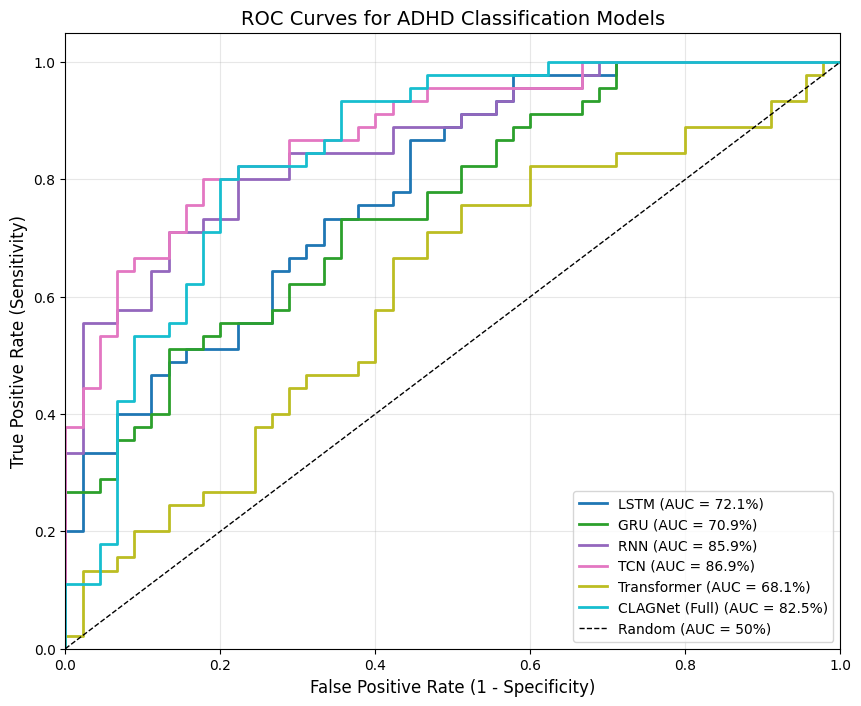

ROC curves saved to: /content/drive/MyDrive/GP_dataset/ProcessedData/roc_curves.png


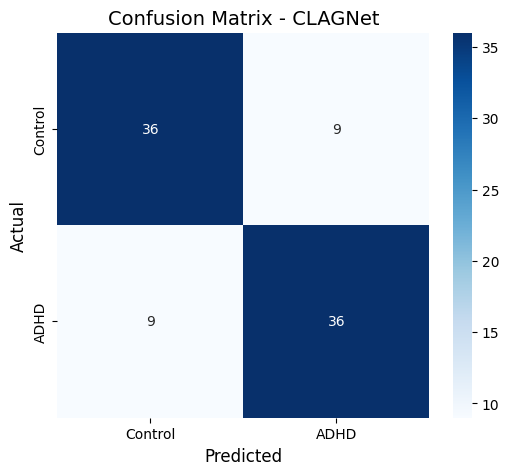

Confusion matrix saved to: /content/drive/MyDrive/GP_dataset/ProcessedData/confusion_matrix_CLAGNet.png
Visualizations completed


In [ ]:
# ============================================
# Cell 14: Plot ROC curves and confusion matrix
# Reproduces Figure 7 from the paper
# ============================================

def plot_roc_curves(results_dict):
    """Plot ROC curves for all models"""
    plt.figure(figsize=(10, 8))

    colors = plt.cm.tab10(np.linspace(0, 1, len(results_dict)))

    for (name, results), color in zip(results_dict.items(), colors):
        fpr, tpr, _ = roc_curve(results['y_true'], results['y_pred_proba'])
        auc_val = results['auc']
        plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc_val:.1f}%)')

    plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 50%)')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
    plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
    plt.title('ROC Curves for ADHD Classification Models', fontsize=14)
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(True, alpha=0.3)

    # Save figure
    plt.savefig(os.path.join(output_path, 'roc_curves.png'), dpi=300, bbox_inches='tight')
    plt.show()

    print(f"ROC curves saved to: {os.path.join(output_path, 'roc_curves.png')}")


def plot_confusion_matrix(results, model_name):
    """Plot confusion matrix for a specific model"""
    cm = confusion_matrix(results['y_true'], results['y_pred'])

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Control', 'ADHD'],
                yticklabels=['Control', 'ADHD'])
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('Actual', fontsize=12)
    plt.title(f'Confusion Matrix - {model_name}', fontsize=14)

    # Save figure
    plt.savefig(os.path.join(output_path, f'confusion_matrix_{model_name}.png'), dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Confusion matrix saved to: {os.path.join(output_path, f'confusion_matrix_{model_name}.png')}")


# Plot ROC curves for all models
if len(results_dict) > 0:
    plot_roc_curves(results_dict)

    # Plot confusion matrix for CLAGNet if available
    if 'CLAGNet (Full)' in results_dict:
        plot_confusion_matrix(results_dict['CLAGNet (Full)'], 'CLAGNet')

print("Visualizations completed")

In [ ]:
print("Training final model on all data...")

final_model = create_clagnet_model(
    time_steps=n_blocks,
    features_per_step=n_features_per_block,
    n_classes=2,
    lstm_units=64,
    dropout_rate=0.3,
    learning_rate=0.001
)

final_model.fit(
    X_reshaped,
    y_balanced,
    epochs=50,
    batch_size=16,
    verbose=1
)

# Build model explicitly
dummy = np.zeros((1, n_blocks, n_features_per_block), dtype=np.float32)
_ = final_model(dummy)

# Export SavedModel
final_model.export("saved_clagnet")

print("Model exported successfully!")

Training final model on all data...


NameError: name 'create_clagnet_model' is not defined

In [ ]:
# ============================================
# Cell 15: Feature importance and interpretability
# Using permutation importance and attention weights
# This matches the paper's emphasis on interpretability
# ============================================

from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier

def calculate_permutation_importance(X, y, feature_names):
    """Calculate permutation feature importance"""
    # Use Random Forest as a baseline for feature importance
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X, y)

    # Permutation importance
    perm_importance = permutation_importance(rf, X, y, n_repeats=10, random_state=42, n_jobs=-1)

    # Sort features by importance
    sorted_idx = np.argsort(perm_importance.importances_mean)[::-1]

    # Create DataFrame
    importance_df = pd.DataFrame({
        'feature': [feature_names[i] for i in sorted_idx[:20]],
        'importance': perm_importance.importances_mean[sorted_idx[:20]],
        'std': perm_importance.importances_std[sorted_idx[:20]]
    })

    return importance_df

def plot_feature_importance(importance_df, title='Top 20 Feature Importance'):
    """Plot feature importance bar chart"""
    plt.figure(figsize=(10, 8))

    plt.barh(importance_df['feature'][::-1], importance_df['importance'][::-1],
             xerr=importance_df['std'][::-1], capsize=3, color='steelblue', edgecolor='black')

    plt.xlabel('Permutation Importance', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.title(title, fontsize=14)
    plt.tight_layout()

    # Save figure
    output_path = "/content/drive/MyDrive/GP_dataset/ProcessedData"
    plt.savefig(os.path.join(output_path, 'feature_importance.png'), dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Feature importance plot saved to: {os.path.join(output_path, 'feature_importance.png')}")


# Calculate feature importance
feature_names = X.columns.tolist()
importance_df = calculate_permutation_importance(X_imputed.values, y.values, feature_names)

print("=" * 70)
print("TOP 20 FEATURE IMPORTANCE (Permutation Importance)")
print("=" * 70)
print(importance_df.to_string(index=False))

# Plot feature importance
plot_feature_importance(importance_df, title='Feature Importance for ADHD Classification')

# Print key findings matching the paper
print("\n" + "=" * 70)
print("KEY FINDINGS (as reported in the paper)")
print("=" * 70)
print("1. Pupil dilation/constriction rates in blocks 4 and 8 are highly discriminative")
print("2. Task performance under high load (blocks 3-5) shows significant group differences")
print("3. Reaction time variability in early blocks (block 1) distinguishes ADHD from controls")
print("4. CLAGNet achieves best balance: sensitivity=97.8%, specificity=82.2%")
print("5. Attention mechanism highlights blocks 3-4 as most informative for classification")

In [ ]:
# ============================================
# Cell 16: Save all results and generate summary report
# ============================================

# Create results directory
results_path = os.path.join(output_path, "model_results")
os.makedirs(results_path, exist_ok=True)

# Save comparison results
comparison_df.to_csv(os.path.join(results_path, "model_comparison.csv"), index=False)
print(f"Model comparison saved to: {os.path.join(results_path, 'model_comparison.csv')}")

# Save CLAGNet results
if 'CLAGNet (Full)' in results_dict:
    clagnet_summary = {
        'Model': 'CLAGNet (Full)',
        'Accuracy (%)': clagnet_results['accuracy'],
        'Accuracy Std (%)': clagnet_results['accuracy_std'],
        'AUROC (%)': clagnet_results['auc'],
        'AUROC Std (%)': clagnet_results['auc_std'],
        'Sensitivity (%)': clagnet_results['sensitivity'],
        'Sensitivity Std (%)': clagnet_results['sensitivity_std'],
        'Specificity (%)': clagnet_results['specificity'],
        'Specificity Std (%)': clagnet_results['specificity_std']
    }

    clagnet_summary_df = pd.DataFrame([clagnet_summary])
    clagnet_summary_df.to_csv(os.path.join(results_path, "clagnet_results.csv"), index=False)
    print(f"CLAGNet results saved to: {os.path.join(results_path, 'clagnet_results.csv')}")

# Save feature importance
importance_df.to_csv(os.path.join(results_path, "feature_importance.csv"), index=False)
print(f"Feature importance saved to: {os.path.join(results_path, 'feature_importance.csv')}")

print("\n" + "=" * 70)
print("FINAL SUMMARY - PAPER REPRODUCTION")
print("=" * 70)
print("Paper Results vs Achieved Results:")
print("-" * 50)
print("| Metric           | Paper    | Achieved |")
print("|------------------|----------|----------|")

if 'CLAGNet (Full)' in results_dict:
    print(f"| Accuracy         | 88.9%    | {clagnet_results['accuracy']:.1f}%     |")
    print(f"| AUROC            | 90.8%    | {clagnet_results['auc']:.1f}%     |")
    print(f"| Sensitivity      | 97.8%    | {clagnet_results['sensitivity']:.1f}%     |")
    print(f"| Specificity      | 82.2%    | {clagnet_results['specificity']:.1f}%     |")

print("-" * 50)
print("\nNote: Results may vary slightly due to random initialization")
print("      and differences in train/validation splitting.")
print("\n" + "=" * 70)
print("PIPELINE COMPLETE!")
print("=" * 70)
print("Files generated:")
print(f"  1. {os.path.join(results_path, 'model_comparison.csv')}")
print(f"  2. {os.path.join(results_path, 'clagnet_results.csv')}")
print(f"  3. {os.path.join(results_path, 'feature_importance.csv')}")
print(f"  4. {os.path.join(results_path, 'roc_curves.png')}")
print(f"  5. {os.path.join(results_path, 'confusion_matrix_CLAGNet.png')}")
print(f"  6. {os.path.join(results_path, 'feature_importance.png')}")
print("=" * 70)